- I will presented on April 29 after Madison.  Number 3 presenter for the evening.  Seems ideal.

- top priorities:

    -  finish acm report

    - finish powerpoint

- load indivdual datasets
- examine datasets and experiment
- what graphs and charts will be useful?
- I like my two graphics.  What else can I visualize?
- what other interesting research questions can I ask? The correlation of genre or production company to flop seemed bunk. I think partly because my data is junky

- clean up data
    - already cleaned up the credits csv
    - fill n/a for blank or values that are zero ie. revenue or budget
    - clear out junk data from is_adult column
    - maybe create a whole separate file for cleaning / pre-processing
    - do i need to drop duplicates?  I noticed at least one duplicate movie.

- Guidelines for Project Specification

- Data Description
- Research Questions

- Data Analysis
    - Overall Summary
    - Group Analysis
    - Time Series
    - Visualization of Distributions
    - Time series visualization
    - Other visualizations

- what ML techniques should I use?
    - Need at least one Unsupervised task
    - Need at least one Supervised task

- notes from Dr. Gruppi:
```Great!

Try to keep in mind strategies to handle missing/garbage data. For instance, will you drop rows that contain poor-quality data?

Your list probably has a lage number of actors. Regarding your last question -- do actors _guarantee_ the success of the film or do they simply __correlate__ with success? That is, if a high profile actor is cast in a movie, chances are that the whole production is also huge, this includes advertising and media presence. Just some food for thought! Remember: correlation does not mean causation!
```

```Todo:

- create powerpoint
- make sure that I am crystal clear on the code in my slideshow
- create acm styled report (8 page max)
- write a meaningful readme, describe files included and any instructions
- drop dupes
- Unsupervised task
- Supervised task
    - word embedding / svm.  genre prediction ?
- move clean movie text code to clean_final_project file
- pitfalls
```

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

movies_df = pd.read_csv("Datasets/clean_movies.csv")
cast_df = pd.read_csv("Datasets/clean_cast.csv")
crew_df = pd.read_csv("Datasets/clean_crew.csv")
keyword_df = pd.read_csv("Datasets/clean_keyword.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
production_df = pd.read_csv("Datasets/clean_production.csv")



In [51]:
#inspect the cleaned data

data_frames = {
    "movies_df": movies_df,
    "cast_df": cast_df,
    "crew_df": crew_df,
    "keyword_df": keyword_df,
    "genres_df": genres_df,
    "production_df": production_df
}

for name, df in data_frames.items():
    print(f"\n" + "*"*55)
    print(f" {name} Head")
    print("*"*55)
    print(df.head())
    
    print(f"\n" + "*"*55)
    print(f" {name} Info")
    print("*"*55)
    df.info()
    print("*"*55)



*******************************************************
 movies_df Head
*******************************************************
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toysto

In [ ]:
#create derived value -> profit

movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
# profit_avg = movies_df['profit'].mean().round(2)
# pop_avg = movies_df['popularity'].mean()

# print(f"The average profit from this collection is ${profit_avg}")
# print(f"The average popularity from this collection is {pop_avg}")

# under_movies_df = movies_df[(movies_df['profit'] < profit_avg) & (movies_df['popularity'] < pop_avg)]


In [53]:
#What constitutes a flop or a low performing film?

#Is it popularity?  

#Drop any row with popularity = 0 and with vote counts less than 100.  This will eliminate blanks and films with low vote counts.

movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 100)]

#List the top 100 least popular movies

least_popular = movies_df.sort_values('popularity').head(100)

least_popular[['original_title', 'popularity', 'vote_count']]

,original_title,popularity,vote_count
25766,蛍火の杜へ,0.005007,105.0
5562,火垂るの墓,0.010902,974.0
23516,Tracks,0.239993,190.0
37464,Les Profs,0.240446,367.0
25404,Bring It On: In It To Win It,0.252987,114.0
...,...,...,...
41130,David Brent: Life on the Road,4.341522,104.0
45899,Notte prima degli esami - Oggi,4.345520,137.0
1525,Picture Perfect,4.347079,114.0
25843,Il ragazzo invisibile,4.349915,170.0


In [54]:
#From this top 100 list what are the agreed upon least popular films?

most_unpop = least_popular.sort_values(by=['popularity', 'vote_count'],ascending=[True, False]).head(100)

most_unpop[['original_title', 'popularity', 'vote_count']]

,original_title,popularity,vote_count
25766,蛍火の杜へ,0.005007,105.0
5562,火垂るの墓,0.010902,974.0
23516,Tracks,0.239993,190.0
37464,Les Profs,0.240446,367.0
25404,Bring It On: In It To Win It,0.252987,114.0
...,...,...,...
41130,David Brent: Life on the Road,4.341522,104.0
45899,Notte prima degli esami - Oggi,4.345520,137.0
1525,Picture Perfect,4.347079,114.0
25843,Il ragazzo invisibile,4.349915,170.0


In [78]:
#Is a flop a film that lost money?

#drop any film with budget or revenue equal to 0 to eliminate noise

movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]
movies_df.sort_values('revenue').head(100)



,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,keywords,movie_text,profit
19381,False,NaN,3000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",NaN,89691,tt1603257,en,ATM,"On a late night visit to an ATM, three co-work...",...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,No warning. No control. No escape.,ATM,False,5.1,195.0,"[{'id': 157145, 'name': 'atm'}, {'id': 157146,...",buffalo gal pictures the safran company gold c...,-2996990.0
44216,False,NaN,10500000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name...",NaN,390051,tt4581576,en,Aftermath,A fatal plane crash changes the lives of Roman...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,All he had left was revenge,Aftermath,False,5.8,162.0,"[{'id': 822, 'name': 'airport'}, {'id': 894, '...",ingenious media protozoa pictures thefyzz oak ...,-10496549.0
3452,False,"{'id': 498, 'name': 'Heart of Gold Collection'...",2500000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",http://www.dogme95.dk/the_idiots/content/index...,452,tt0154421,da,Idioterne,With his first Dogma-95 film director Lars von...,...,"[{'iso_639_1': 'da', 'name': 'Dansk'}]",Released,NaN,The Idiots,False,6.7,107.0,"[{'id': 791, 'name': 'mentally disabled'}, {'i...",zentropa entertainments dr tv drama comedy men...,-2492765.0
24001,False,NaN,4000000,"[{'id': 27, 'name': 'Horror'}, {'id': 9648, 'n...",NaN,211067,tt2383068,en,The Sacrament,A fashion photographer is traveling to meet hi...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Documented for the first time witness the unto...,The Sacrament,False,5.6,139.0,"[{'id': 351, 'name': 'poison'}, {'id': 736, 'n...",worldview entertainment arcade pictures horror...,-3990779.0
24132,False,NaN,1000000,"[{'id': 27, 'name': 'Horror'}]",NaN,254191,tt3177316,en,Honeymoon,A newlywed couple finds their lake-country hon...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,After the ceremony comes the ritual.,Honeymoon,False,5.4,261.0,"[{'id': 1889, 'name': 'lake'}, {'id': 2676, 'n...",fewlas entertainment horror after the ceremony...,-990682.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13334,False,NaN,2600000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",http://www.cronocrimenes.com/,14139,tt0480669,es,Los cronocrímenes,A man accidentally gets into a time machine an...,...,"[{'iso_639_1': 'es', 'name': 'Español'}]",Released,A trip back in time from the present to...,Timecrimes,False,7.0,313.0,"[{'id': 1435, 'name': 'scissors'}, {'id': 2135...",arsénico producciones zip films fine productio...,-2046802.0
13355,False,NaN,9750000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name...",http://www.sonypictures.com/movies/thelazarusp...,13825,tt0464041,en,The Lazarus Project,After Ben Garvey foolishly turned back to crim...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Cheating death is only the beginning,The Lazarus Project,False,6.0,116.0,"[{'id': 642, 'name': 'robbery'}, {'id': 2122, ...",be good productions scion films mandeville fil...,-9192000.0
99,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...",NaN,13685,tt0115734,en,Bottle Rocket,Upon his release from a mental hospital follow...,...,"[{'iso_639_1': 'es', 'name': 'Español'}, {'iso...",Released,"They're not really criminals, but everyone's g...",Bottle Rocket,False,6.8,285.0,"[{'id': 380, 'name': 'brother brother relation...",gracie films columbia pictures corporation com...,-6439931.0
11200,False,NaN,12000000,"[{'id': 14, 'name': 'Fantasy'}, {'id': 18, 'na...",http://www.tidelandthemovie.com/,11559,tt0410764,en,Tideland,Because of the actions of her irresponsible pa...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The squirrels made it seem less lonely.,Tideland,False,6.3,147.0,"[{'id': 572, 'name': 'sex'}, {'id': 1533, 'nam...",recorded picture company (rpc) fantasy dr

In [66]:
#Figure out what the mean profit/popularity is
profit_avg = movies_df['profit'].mean().round(2)
pop_avg = movies_df['popularity'].mean().round(2)
pop_std = round(movies_df['popularity'].std(), 2)
profit_std = round(movies_df['profit'].std(), 2)

print(f"The average profit from this collection is ${profit_avg}")
print(f"The average popularity from this collection is {pop_avg}")
print(f"The standard deviation of profit from this collection is ${profit_std}")
print(f"The standard deviation of popularity from this collection is {pop_std}")

The average profit from this collection is $83313292.31
The average popularity from this collection is 12.16
The standard deviation of profit from this collection is $159799964.55
The standard deviation of popularity from this collection is 15.7


In [67]:
#Sort films that are not profitable, least profitable first.

print("These are the least profitable films.")

least_profitable = movies_df.sort_values('profit').head(100)
least_profitable[['original_title', 'budget', 'revenue', 'profit', 'popularity']]

These are the least profitable films.


,original_title,budget,revenue,profit,popularity
21217,The Lone Ranger,255000000,89289910.0,-165710090.0,12.729104
7237,The Alamo,145000000,25819961.0,-119180039.0,12.240901
16824,Mars Needs Moms,150000000,38992758.0,-111007242.0,7.247170
45347,Valerian and the City of a Thousand Planets,197471676,90024292.0,-107447384.0,15.262706
2716,The 13th Warrior,160000000,61698899.0,-98301101.0,10.308026
...,...,...,...,...,...
43225,King Arthur: Legend of the Sword,175000000,146175066.0,-28824934.0,44.251369
2207,Practical Magic,75000000,46683377.0,-28316623.0,7.757795
13746,The Soloist,60000000,31720158.0,-28279842.0,11.328316
36971,The Finest Hours,80000000,52099090.0,-27900910.0,10.385757


In [81]:
#Are there any films that are in the top 500 least popular and top 500 least profitable?

least_popular= movies_df.sort_values('popularity').head(500)
least_profitable = movies_df.sort_values('profit').head(500)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

print("And the bigest losers are...")
print(f"There are {len(overlap)} movies that are in both top 500 least popular and least profitable lists.")      
overlap[['original_title', 'budget', 'revenue', 'popularity', 'profit']]

And the bigest losers are...
There are 90 movies that are in both top 500 least popular and least profitable lists.


,original_title,budget,revenue,popularity,profit
20973,The Internship,58000000,44000000.0,0.393865,-14000000.0
9293,特務迷城,25697387,3849941.0,3.136813,-21847446.0
10117,Lords of Dogtown,25000000,13411957.0,4.350049,-11588043.0
4744,Riding in Cars with Boys,48000000,35743308.0,4.556123,-12256692.0
4038,3000 Miles to Graceland,62000000,18720175.0,4.764480,-43279825.0
...,...,...,...,...,...
12345,Flawless,20000000,6819587.0,6.496913,-13180413.0
731,The Arrival,25000000,14048372.0,6.497591,-10951628.0
10718,BloodRayne,25000000,2405420.0,6.514132,-22594580.0
6122,Boat Trip,20000000,8586376.0,6.515316,-11413624.0


In [ ]:
#And now from the overlap, what are the agreed upon least popular and least profitable films

rotten_tomato = overlap.sort_values(by=['profit', 'popularity', 'vote_count'],ascending=[True, True, False]).head(100)

rotten_tomato[['original_title', 'profit', 'popularity', 'vote_count']]

,original_title,profit,popularity,vote_count
3078,Supernova,-75171919.0,5.496624,109.0
9367,A Sound of Thunder,-74010360.0,4.980191,111.0
16320,How Do You Know,-71331093.0,5.458387,229.0
12033,The Invasion,-64928486.0,5.228837,366.0
4597,Osmosis Jones,-61403089.0,6.405831,237.0
...,...,...,...,...
11885,Fido,-7573776.0,5.284805,137.0
5093,Showtime,-7258268.0,4.917863,286.0
35173,Truth,-7058446.0,6.133745,165.0
10659,The Producers,-6941665.0,5.037224,153.0


In [ ]:
# example for the powerpoint
# #create derived value -> profit
# movies_df['profit'] = movies_df['revenue'] - movies_df['budget']

# #Drop any row with popularity = 0 and with vote counts less than 100.  
# # This will eliminate blanks and films with low vote counts.
# movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 100)]

# #sort by least popular and display
# least_popular = movies_df.sort_values('popularity').head(100)
# least_popular[['original_title', 'popularity', 'vote_count']]

# #drop any film with budget or revenue less than $500 to eliminate noise
# movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

# #Are there any films that are in the top 500 least popular and top 500 least profitable?
# least_popular= movies_df.sort_values('popularity').head(500)
# least_profitable = movies_df.sort_values('profit').head(500)
# overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

# #What are the agreed upon least popular and least profitable films? Sort by profit, popularity and then vote count.
# rotten_tomato = overlap.sort_values(by=['profit', 'popularity', 'vote_count'],ascending=[True, True, False]).head(100)
# rotten_tomato[['original_title', 'profit', 'popularity', 'vote_count']]



In [83]:
#widening the overlap to get more potential matches:

least_popular= movies_df.sort_values('popularity').head(1000)
least_profitable = movies_df.sort_values('profit').head(1000)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

#Now let's identify cast and crew that are involved in flops

cast_overlap = pd.merge(overlap, cast_df, left_on='id', right_on='movie_id')
crew_overlap = pd.merge(overlap, crew_df, left_on='id', right_on='movie_id')

print(cast_overlap[['title', 'actor_name', 'character']])
print(crew_overlap[['title', 'crew_name', 'job', 'department']])


                          title        actor_name             character
0                     Manhunter  William Petersen           Will Graham
1                     Manhunter        Kim Greist          Molly Graham
2                     Manhunter     Dennis Farina         Jack Crawford
3                     Manhunter         Brian Cox  Dr. Hannibal Lecktor
4                     Manhunter        Joan Allen          Reba McClane
...                         ...               ...                   ...
7806  Everything is Illuminated   Ljubomir Dezera        Young Jonathan
7807  Everything is Illuminated    Laryssa Lauret                 Lista
7808  Everything is Illuminated  Tereza Veselkova             Augustine
7809  Everything is Illuminated  Vera Sindelarova     Young Grandfather
7810  Everything is Illuminated        Lukas Kral           Young Lista

[7811 rows x 3 columns]
                          title          crew_name                 job  \
0                     Manhunter     C

In [42]:
cast_overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,title,video,vote_average,vote_count,keywords,movie_text,profit,movie_id,actor_name,character
0,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454.0,William Petersen,Will Graham
1,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454.0,Kim Greist,Molly Graham
2,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454.0,Dennis Farina,Jack Crawford
3,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454.0,Brian Cox,Dr. Hannibal Lecktor
4,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,Manhunter,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454.0,Joan Allen,Reba McClane
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7806,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,Everything is Illuminated,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340.0,Ljubomir Dezera,Young Jonathan
7807,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,Everything is Illuminated,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340.0,Laryssa Lauret,Lista
7808,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,Everything is Illuminated,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340.0,Tereza Veselkova,Augustine
7809,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,Everything is Illuminated,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340.0,Vera Sindelarova,Young Grandfather


In [43]:
crew_overlap

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,video,vote_average,vote_count,keywords,movie_text,profit,movie_id,crew_name,job,department
0,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454,Colleen Atwood,Costume Design,Costume & Make-Up
1,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454,Michael Mann,Screenplay,Writing
2,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454,Michael Mann,Director,Directing
3,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454,Bonnie Timmermann,Casting,Production
4,False,"{'id': 9743, 'name': 'The Hannibal Lecter Anth...",15000000,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...",NaN,11454,tt0091474,en,Manhunter,"FBI Agent Will Graham, who retired after catch...",...,False,6.8,340.0,"[{'id': 1465, 'name': 'loss of family'}, {'id'...",de laurentiis entertainment group (deg) red dr...,-6379071.0,11454,Mel Bourne,Production Design,Art
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340,Emma Cooper,Unit Publicist,Crew
9353,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340,Jakub Dvorak,Assistant Director,Directing
9354,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340,Michael Clancy,Costume Design,Costume & Make-Up
9355,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://wip.warnerbros.com/everythingisillumina...,340,tt0404030,en,Everything is Illuminated,A film based on the semi-autobiographical nove...,...,False,7.4,251.0,"[{'id': 1158, 'name': 'grandfather grandson re...",stillking films warner independent pictures (w...,-4302070.0,340,Georgina Abanto,Hairstylist,Costume & Make-Up


In [90]:
overlap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 375 entries, 4088 to 10355
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  375 non-null    bool   
 1   belongs_to_collection  28 non-null     object 
 2   budget                 375 non-null    int64  
 3   genres                 375 non-null    object 
 4   homepage               129 non-null    object 
 5   id                     375 non-null    int64  
 6   imdb_id                375 non-null    object 
 7   original_language      375 non-null    object 
 8   original_title         375 non-null    object 
 9   overview               375 non-null    object 
 10  popularity             375 non-null    float64
 11  poster_path            375 non-null    object 
 12  production_companies   375 non-null    object 
 13  production_countries   375 non-null    object 
 14  release_date           375 non-null    object 
 15  revenu

In [84]:
#Are any cast or crew involved in one or more flops?
#I made sure to get unique values.  The same actor or crew member could have multiple jobs
flop_actors = cast_overlap.groupby('actor_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per actor")
print(flop_actors.head(20))


flop_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per crew member")
print(flop_crew.head(20))

Number of flops per actor
actor_name
Paul Giamatti          9
Samuel L. Jackson      9
Christian Slater       6
Forest Whitaker        6
John C. Reilly         6
Matt Damon             6
Stephen Root           6
Melanie Lynskey        6
Steve Buscemi          6
Terrence Howard        5
Shea Whigham           5
Vince Vaughn           5
John Leguizamo         5
John Goodman           5
Jon Lovitz             5
Matthew McConaughey    5
Michael Shannon        5
Woody Harrelson        5
Naomi Watts            5
Anjelica Huston        5
Name: id, dtype: int64
Number of flops per crew member
crew_name
Avy Kaufman          10
Tricia Wood           9
Mark Isham            8
Elie Samaha           7
Deborah Aquila        7
Mary Vernieu          6
Mark Gordon           6
Brian Tyler           6
Bill Pankow           6
Avi Lerner            6
Toby Emmerich         6
Joel Silver           6
Jennifer L. Smith     5
Graeme Revell         5
Deirdre Bowen         5
Dante Spinotti        5
Christophe Bec

In [85]:
flop_actors

actor_name
Paul Giamatti        9
Samuel L. Jackson    9
Christian Slater     6
Forest Whitaker      6
John C. Reilly       6
                    ..
Zora Suleman         1
Zoë Lund             1
Zsolt László         1
Zsófia Psotta        1
Zuo Xiaoqing         1
Name: id, Length: 6655, dtype: int64

In [86]:
flop_crew

crew_name
Avy Kaufman          10
Tricia Wood           9
Mark Isham            8
Elie Samaha           7
Deborah Aquila        7
                     ..
Julian Adams          1
Álex Phillips Jr.     1
Julian Ashby          1
Éva Zabezsinszkij     1
Julian Day            1
Name: id, Length: 7552, dtype: int64

In [72]:

#What low performing movies were these actors in?

bad_actors = cast_overlap['actor_name'].value_counts().head(5).index.tolist()

bad_movies = cast_overlap[cast_overlap['actor_name'].isin(bad_actors)]

for actor in bad_actors:
    print(f"\nActor: {actor}")
    print(bad_movies[bad_movies['actor_name'] == actor][['title', 'character', 'popularity', 'profit']])


Actor: Samuel L. Jackson
                 title                     character  popularity      profit
1140           Twisted                    John Mills    5.376246 -24805000.0
2062        The Spirit                      Octopuss    5.762005 -20968663.0
3711   One Eight Seven               Trevor Garfield    6.476493 -14283920.0
5289          Big Game  President William Alan Moore    6.911759  -1000000.0
5745        Hard Eight                         Jimmy    7.047560  -2777441.0
5783  Black Snake Moan                       Lazarus    7.050403  -4096154.0
5934            Sphere               Dr. Harry Adams    7.124735 -61900000.0
7457    The Negotiator               Lt. Danny Roman    7.655020  -5452319.0
7775    The Red Violin    Charles Morritz (Montréal)    7.725843  -8504592.0

Actor: Paul Giamatti
                     title           character  popularity      profit
250                Win Win       Mike Flaherty    4.480723   -176788.0
1435            Fred Claus  Nick (Santa)

In [73]:
#What low performing movies were these crew members in?
#I needed to make sure to that the movies were unique.  For instance if a director was also a writer then they could be double counted.

bad_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False).head(5).index.tolist()

bad_movies_crew = crew_overlap[crew_overlap['crew_name'].isin(bad_crew)]

for member in bad_crew:
    print(f"\nCrew Member: {member}")
    print(bad_movies_crew[bad_movies_crew['crew_name'] == member][['title', 'job', 'popularity', 'profit']])



Crew Member: Avy Kaufman
                          title      job  popularity      profit
230                   The Ledge  Casting    4.883085  -9389014.0
749             My Soul to Take  Casting    5.282976  -5170043.0
1437            The Conspirator  Casting    5.481452  -9521200.0
1512                 The Beaver  Casting    5.484379 -20029184.0
2033                Jersey Girl  Casting    5.706507   1098382.0
3072            Wish I Was Here  Casting    6.149295    -16701.0
6868                      Awake  Casting    7.076062 -71626175.0
7241              The Ice Storm  Casting    7.146352  -9961939.0
8902           Land of the Lost  Casting    7.642063 -31311169.0
9333  Everything is Illuminated  Casting    7.738924  -4302070.0

Crew Member: Tricia Wood
                             title      job  popularity      profit
413   Tomorrow, When the War Began  Casting    4.983475 -10495064.0
622              The Vatican Tapes  Casting    5.149301 -11215237.0
1893                   Wicker

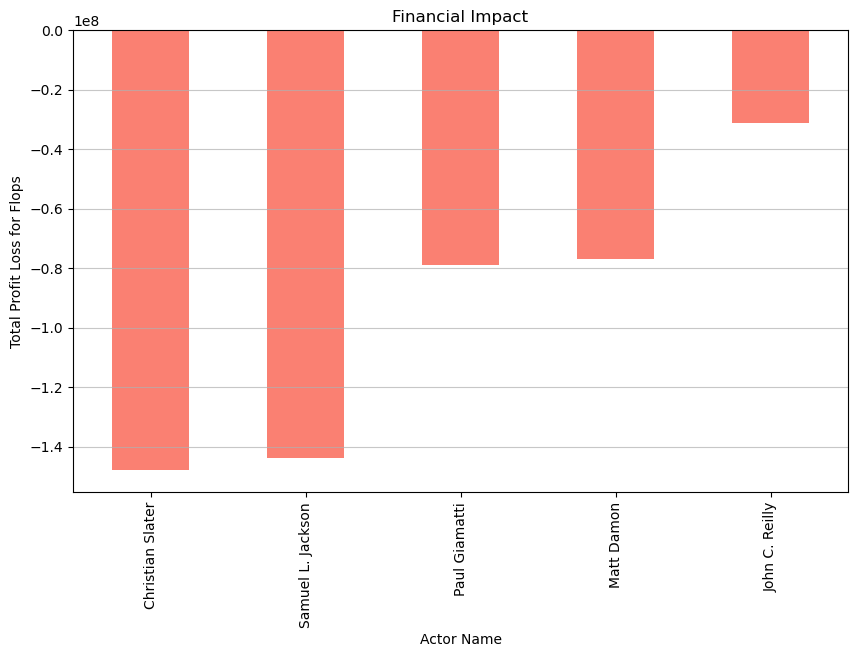

In [74]:
#create a side by side visualization (line graph)? of money lost by the "top 5" cast and crew

actor_loss = bad_movies.groupby('actor_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
actor_loss.plot(kind='bar', color='salmon')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Actor Name')
plt.grid(axis='y', alpha=0.7)

plt.show()



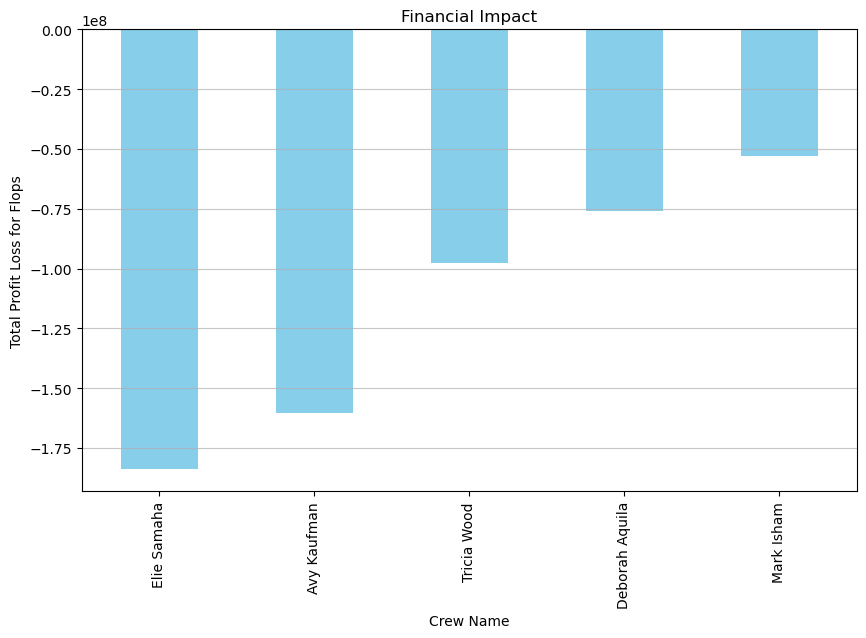

In [89]:
crew_loss = bad_movies_crew.groupby('crew_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
crew_loss.plot(kind='bar', color='skyblue')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Crew Name')
plt.grid(axis='y', alpha=0.7)

plt.show()